# TM EI 的干预尺度基线实验

这个 notebook 只回答一个问题：当干预区间长度 $L$ 改变时，传输映射估计的有效信息 $EI$ 为什么会变，以及不同 baseline 本身能解释多少这种变化。

这里不再画 $EI_{\mathrm{raw}}(L)-B_b(L)$ 的作差曲线。图中展示的是原始 $EI_{\mathrm{raw}}(L)$ 和 baseline 自身 $B_b(L)$，便于直接比较 baseline 如何随 $L$ 变化。


## 实验设定

对每个一维动力学函数 $F\in\{x,x^2,\sin(x),\exp(x)\}$，在给定 $L$ 时采样

$$
x_i\sim \mathrm{Uniform}([-L/2,L/2]),\qquad y_i=F(x_i)+\epsilon_i .
$$

原始有效信息为

$$
EI_{\mathrm{raw}}(L)=\widehat I_{\mathrm{TM}}(\phi(x);y).
$$

每个 baseline 都在同一个 $L$、同一批源样本下构造一个参照目标 $\tilde y^{(b)}$，然后计算

$$
B_b(L)=\widehat I_{\mathrm{TM}}(\phi(x);\tilde y^{(b)}).
$$

本 notebook 仍然计算 $EI_{\mathrm{raw}}(L)-B_b(L)$ 用于选择斜率更平的 baseline，但主图只画 $B_b(L)$ 本身。


In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import numpy as np

from IPython.display import Image, display

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == 'exp':
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from utils import (
    DEFAULT_BASELINES,
    REQUESTED_ONE_DIMENSIONAL_DYNAMICS_SPECS,
    plot_raw_ei_by_center,
    plot_raw_vs_selected_baselines_by_l,
    select_top_global_baselines,
    run_ei_center_sweep,
    run_ei_l_baseline_sweep,
    write_center_sweep_artifacts,
    write_experiment_artifacts,
)

OUTPUT_DIR = REPO_ROOT / 'fig' / 'transport_map_mutual_information'
TEST_MODE = os.environ.get('YRD_NOTEBOOK_TEST_MODE', '').strip() == '1'
SEED = 20260429

CONFIG = {
    'l_values': (1.0, 2.0, 4.0) if TEST_MODE else (0.5, 1.0, 2.0, 4.0, 8.0, 12.0, 16.0),
    'dynamics_specs': REQUESTED_ONE_DIMENSIONAL_DYNAMICS_SPECS,
    'baselines': DEFAULT_BASELINES,
    'n_samples': 512 if TEST_MODE else 4096,
    'sample_count_mode': 'fixed_density',
    'reference_l': 4.0,
    'min_n_samples': 128 if TEST_MODE else 512,
    'max_n_samples': None,
    'repeats': 2 if TEST_MODE else 10,
    'base_noise_std': 0.05,
    'noise_modes': ('fixed',) if TEST_MODE else ('fixed', 'scaled_with_l'),
    'seed': SEED,
}

results = run_ei_l_baseline_sweep(**CONFIG)
runs = results['runs']
baselines = results['baselines']
corrected = results['corrected']
summary = results['summary']

artifact_paths = write_experiment_artifacts(
    results=results,
    output_dir=OUTPUT_DIR,
    notebook_path='exp/tm_ei_l_baseline.ipynb',
    config={
        **CONFIG,
        'dynamics_specs': [dict(spec) for spec in CONFIG['dynamics_specs']],
        'baselines': list(CONFIG['baselines']),
        'l_values': list(CONFIG['l_values']),
        'noise_modes': list(CONFIG['noise_modes']),
        'test_mode': TEST_MODE,
    },
)

{
    'runs': runs.shape,
    'baselines': baselines.shape,
    'corrected': corrected.shape,
    'summary': summary.shape,
    'artifacts': artifact_paths,
}


{'runs': (560, 13),
 'baselines': (3360, 15),
 'corrected': (3360, 23),
 'summary': (48, 11),
 'artifacts': {'runs_csv': '/Users/yangmingzhe/Desktop/code/github/EISyn/fig/transport_map_mutual_information/tm_ei_l_baseline_runs.csv',
  'baselines_csv': '/Users/yangmingzhe/Desktop/code/github/EISyn/fig/transport_map_mutual_information/tm_ei_l_baseline_baselines.csv',
  'corrected_csv': '/Users/yangmingzhe/Desktop/code/github/EISyn/fig/transport_map_mutual_information/tm_ei_l_baseline_corrected.csv',
  'summary_csv': '/Users/yangmingzhe/Desktop/code/github/EISyn/fig/transport_map_mutual_information/tm_ei_l_baseline_summary.csv',
  'manifest_json': '/Users/yangmingzhe/Desktop/code/github/EISyn/fig/transport_map_mutual_information/tm_ei_l_baseline_manifest.json'}}

## Baseline 的数学构造

这里先只写一维情形，因为本 notebook 的输入都是一维。固定一个干预尺度 $L$，记样本为 $i=1,\ldots,n$。

符号定义：

- $L>0$：干预区间长度，源变量从 $[-L/2,L/2]$ 采样。
- $x_i$：第 $i$ 个源变量样本。
- $F$：真实动力学函数，例如 $F(x)=x$、$x^2$、$\sin(x)$ 或 $\exp(x)$。
- $s_i=F(x_i)$：真实动力学的无噪声输出信号。
- $\tilde\epsilon_i$：baseline 里额外加入的噪声，噪声强度与真实实验中的目标噪声相同。
- $\tilde y_i$：baseline 构造出来的参照目标。
- $\phi(x)$：传输映射估计器使用的源变量特征。
- $\widehat I_{\mathrm{TM}}(\phi(x);\tilde y)$：用传输映射方法估计的 $\phi(x)$ 与 $\tilde y$ 之间的互信息。
- $B(L)$：在干预尺度 $L$ 下得到的 baseline EI。

### `identity` baseline

构造方式最简单：把源变量原样传到目标端，再加同等噪声。

$$
\tilde y_i^{\mathrm{id}}=x_i+\tilde\epsilon_i,
\qquad
B_{\mathrm{id}}(L)=\widehat I_{\mathrm{TM}}(\phi(x);\tilde y^{\mathrm{id}}).
$$

其中 $\tilde y_i^{\mathrm{id}}$ 是第 $i$ 个 `identity` baseline 目标；$\tilde y^{\mathrm{id}}$ 表示由所有 $\tilde y_i^{\mathrm{id}}$ 组成的目标样本；$B_{\mathrm{id}}(L)$ 是这条 baseline 在尺度 $L$ 下的 EI。

设计依据：`identity` 是最基本的一对一线性参照。它回答：如果系统没有非线性，只是“输出等于输入”，在同样的 $L$ 和噪声下会产生多少 EI。因此它主要控制“输入范围变大 + 固定噪声”带来的线性可区分性增长。

### `variance_matched` baseline

先定义两个统计量。对任意一组数 $u_1,\ldots,u_n$，记

$$
\bar u=\frac1n\sum_{i=1}^n u_i,
\qquad
\operatorname{sd}(u)=\sqrt{\frac1{n-1}\sum_{i=1}^n (u_i-\bar u)^2}.
$$

其中 $\bar u$ 是样本均值，$\operatorname{sd}(u)$ 是样本标准差。

`variance_matched` baseline 仍然使用线性输入 $x_i$，但把它平移和缩放到与真实信号 $s_i=F(x_i)$ 有相同均值和相同标准差：

$$
\tilde s_i^{\mathrm{var}}
=\bar s+\frac{x_i-\bar x}{\operatorname{sd}(x)}\operatorname{sd}(s),
\qquad
\tilde y_i^{\mathrm{var}}=\tilde s_i^{\mathrm{var}}+\tilde\epsilon_i .
$$

其中 $\bar x$ 和 $\operatorname{sd}(x)$ 是源样本 $x_1,\ldots,x_n$ 的均值和标准差；$\bar s$ 和 $\operatorname{sd}(s)$ 是真实无噪声信号 $s_1,\ldots,s_n$ 的均值和标准差；$\tilde s_i^{\mathrm{var}}$ 是方差匹配后的线性参照信号；$\tilde y_i^{\mathrm{var}}$ 是加噪后的 baseline 目标。

对应的 baseline EI 是

$$
B_{\mathrm{var}}(L)=\widehat I_{\mathrm{TM}}(\phi(x);\tilde y^{\mathrm{var}}).
$$

其中 $\tilde y^{\mathrm{var}}$ 表示由所有 $\tilde y_i^{\mathrm{var}}$ 组成的目标样本；$B_{\mathrm{var}}(L)$ 是 `variance_matched` baseline 在尺度 $L$ 下的 EI。

设计依据：很多动力学的 EI 会随 $L$ 增大，不只是因为关系更复杂，也可能只是因为输出幅度变大。例如 $x^2$ 和 $\exp(x)$ 的输出方差会随 $L$ 快速增加。`variance_matched` 保留“线性可预测关系”，并强制它拥有与真实信号相同的输出均值和输出方差；因此它回答：如果只控制输出尺度，而不引入真实非线性，会产生多少 EI。

简单说，`identity` 控制最基本的线性恒等效应；`variance_matched` 进一步控制真实输出尺度变大带来的效应。两者都是线性 baseline，目的不是复现 $F$，而是给原始 EI 提供可解释的线性参照。


,baseline,mean_abs_corrected_slope,median_abs_corrected_slope,max_abs_corrected_slope,n_cases
0,variance_matched,0.743092,0.390815,2.189835,4
1,identity,0.800296,0.922976,1.351159,4


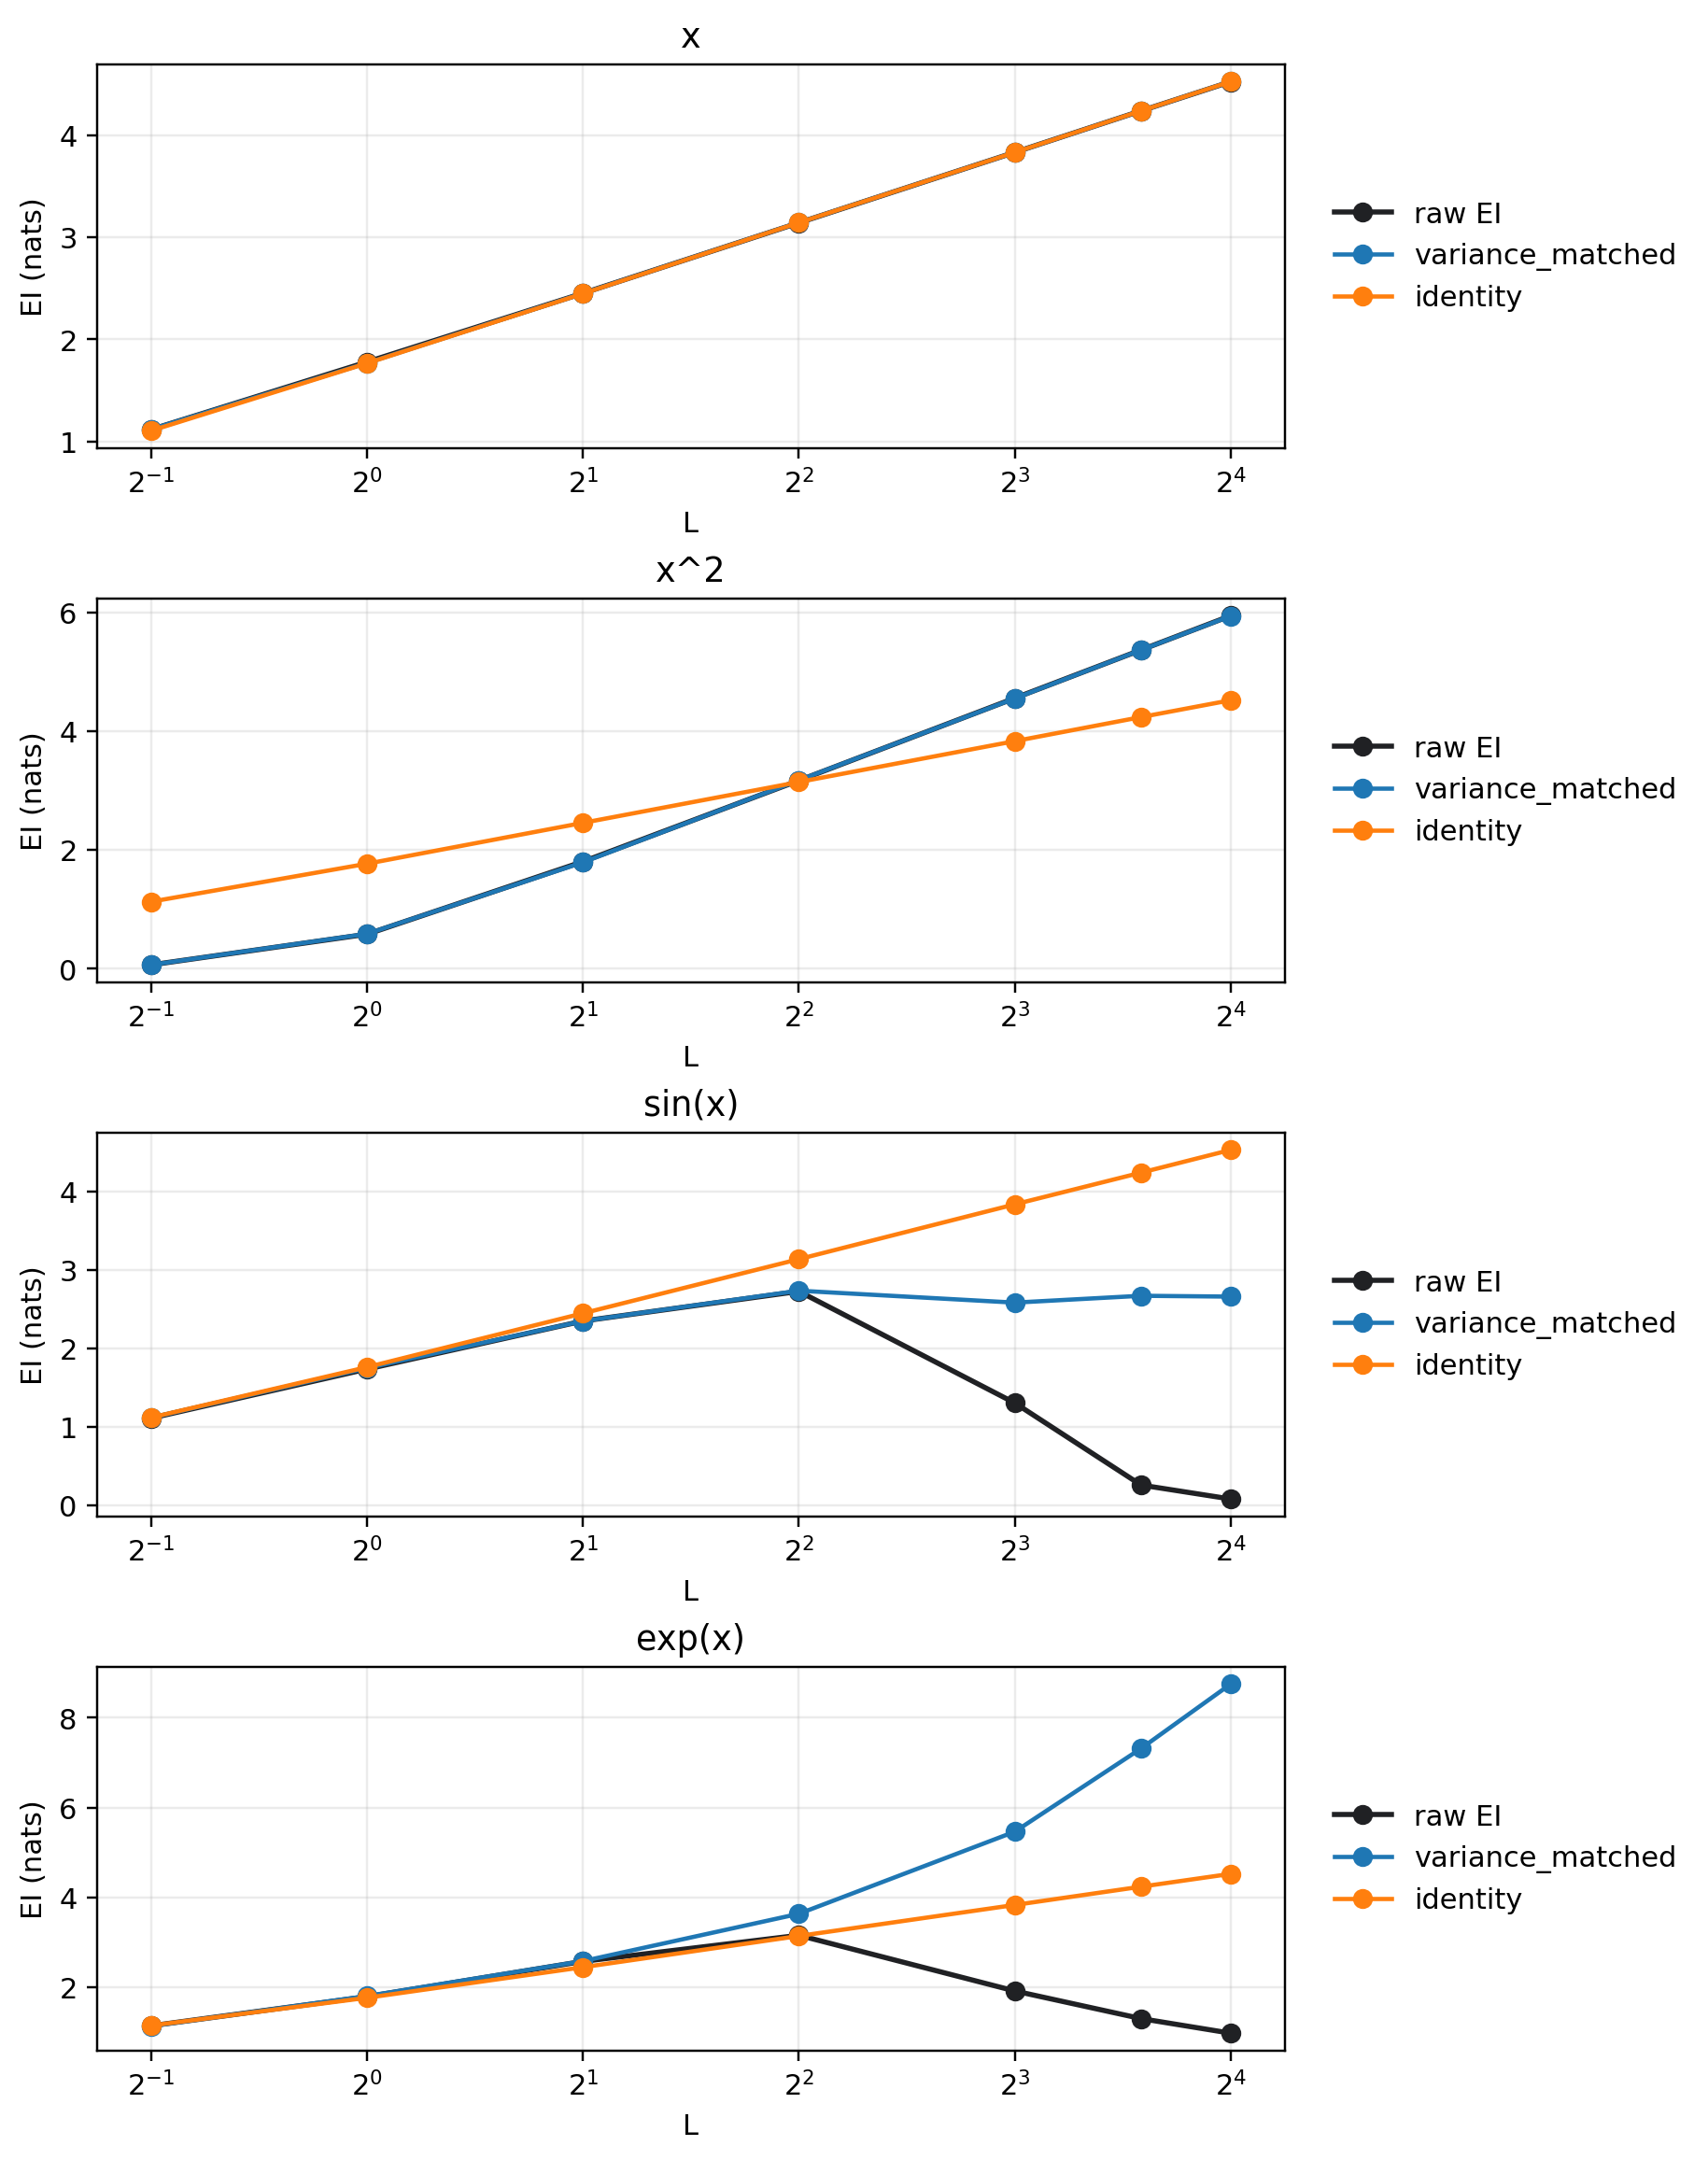

{'selected_baselines': ['variance_matched', 'identity'],
 'top2_baseline_curves': ['/Users/yangmingzhe/Desktop/code/github/EISyn/fig/transport_map_mutual_information/tm_ei_l_baseline_top2_baseline_comparison.png',
  '/Users/yangmingzhe/Desktop/code/github/EISyn/fig/transport_map_mutual_information/tm_ei_l_baseline_top2_baseline_comparison.pdf']}

In [2]:
TOP_BASELINE_CANDIDATES = ('identity', 'gain_matched', 'variance_matched', 'analytic_volume')
top2_baseline_ranking = select_top_global_baselines(
    summary,
    noise_mode='fixed',
    candidate_baselines=TOP_BASELINE_CANDIDATES,
    top_n=2,
)
top2_baselines = tuple(top2_baseline_ranking['baseline'].tolist())
display(top2_baseline_ranking)

top2_baseline_png, top2_baseline_pdf, top2_curve_table = plot_raw_vs_selected_baselines_by_l(
    runs,
    baselines,
    output_dir=OUTPUT_DIR,
    noise_mode='fixed',
    dynamics_labels=tuple(dict.fromkeys(runs['label'].tolist())),
    baselines=top2_baselines,
    output_stem='tm_ei_l_baseline_top2_baseline_comparison',
)
display(Image(filename=str(top2_baseline_png)))
{
    'selected_baselines': list(top2_baselines),
    'top2_baseline_curves': [str(top2_baseline_png), str(top2_baseline_pdf)],
}


## 固定 $L$ 后改变采样中心

上面的实验把采样区间固定在原点附近，并改变区间长度 $L$。这里反过来固定区间长度 $L=4.0$，只改变采样中心 $c$：

$$
x_i\sim \mathrm{Uniform}([c-L/2,c+L/2]),\qquad y_i=F(x_i)+\epsilon_i .
$$

完整实验使用 $c\in[-8,8]$ 的 17 个等距中心点，例子仍然是 $x$、$x^2$、$\sin(x)$ 和 $\exp(x)$。图中保持前一组图的呈现方式：黑线为原始 $EI$，彩色线为选中的 baseline 本身，而不是 baseline 扣除后的差值。


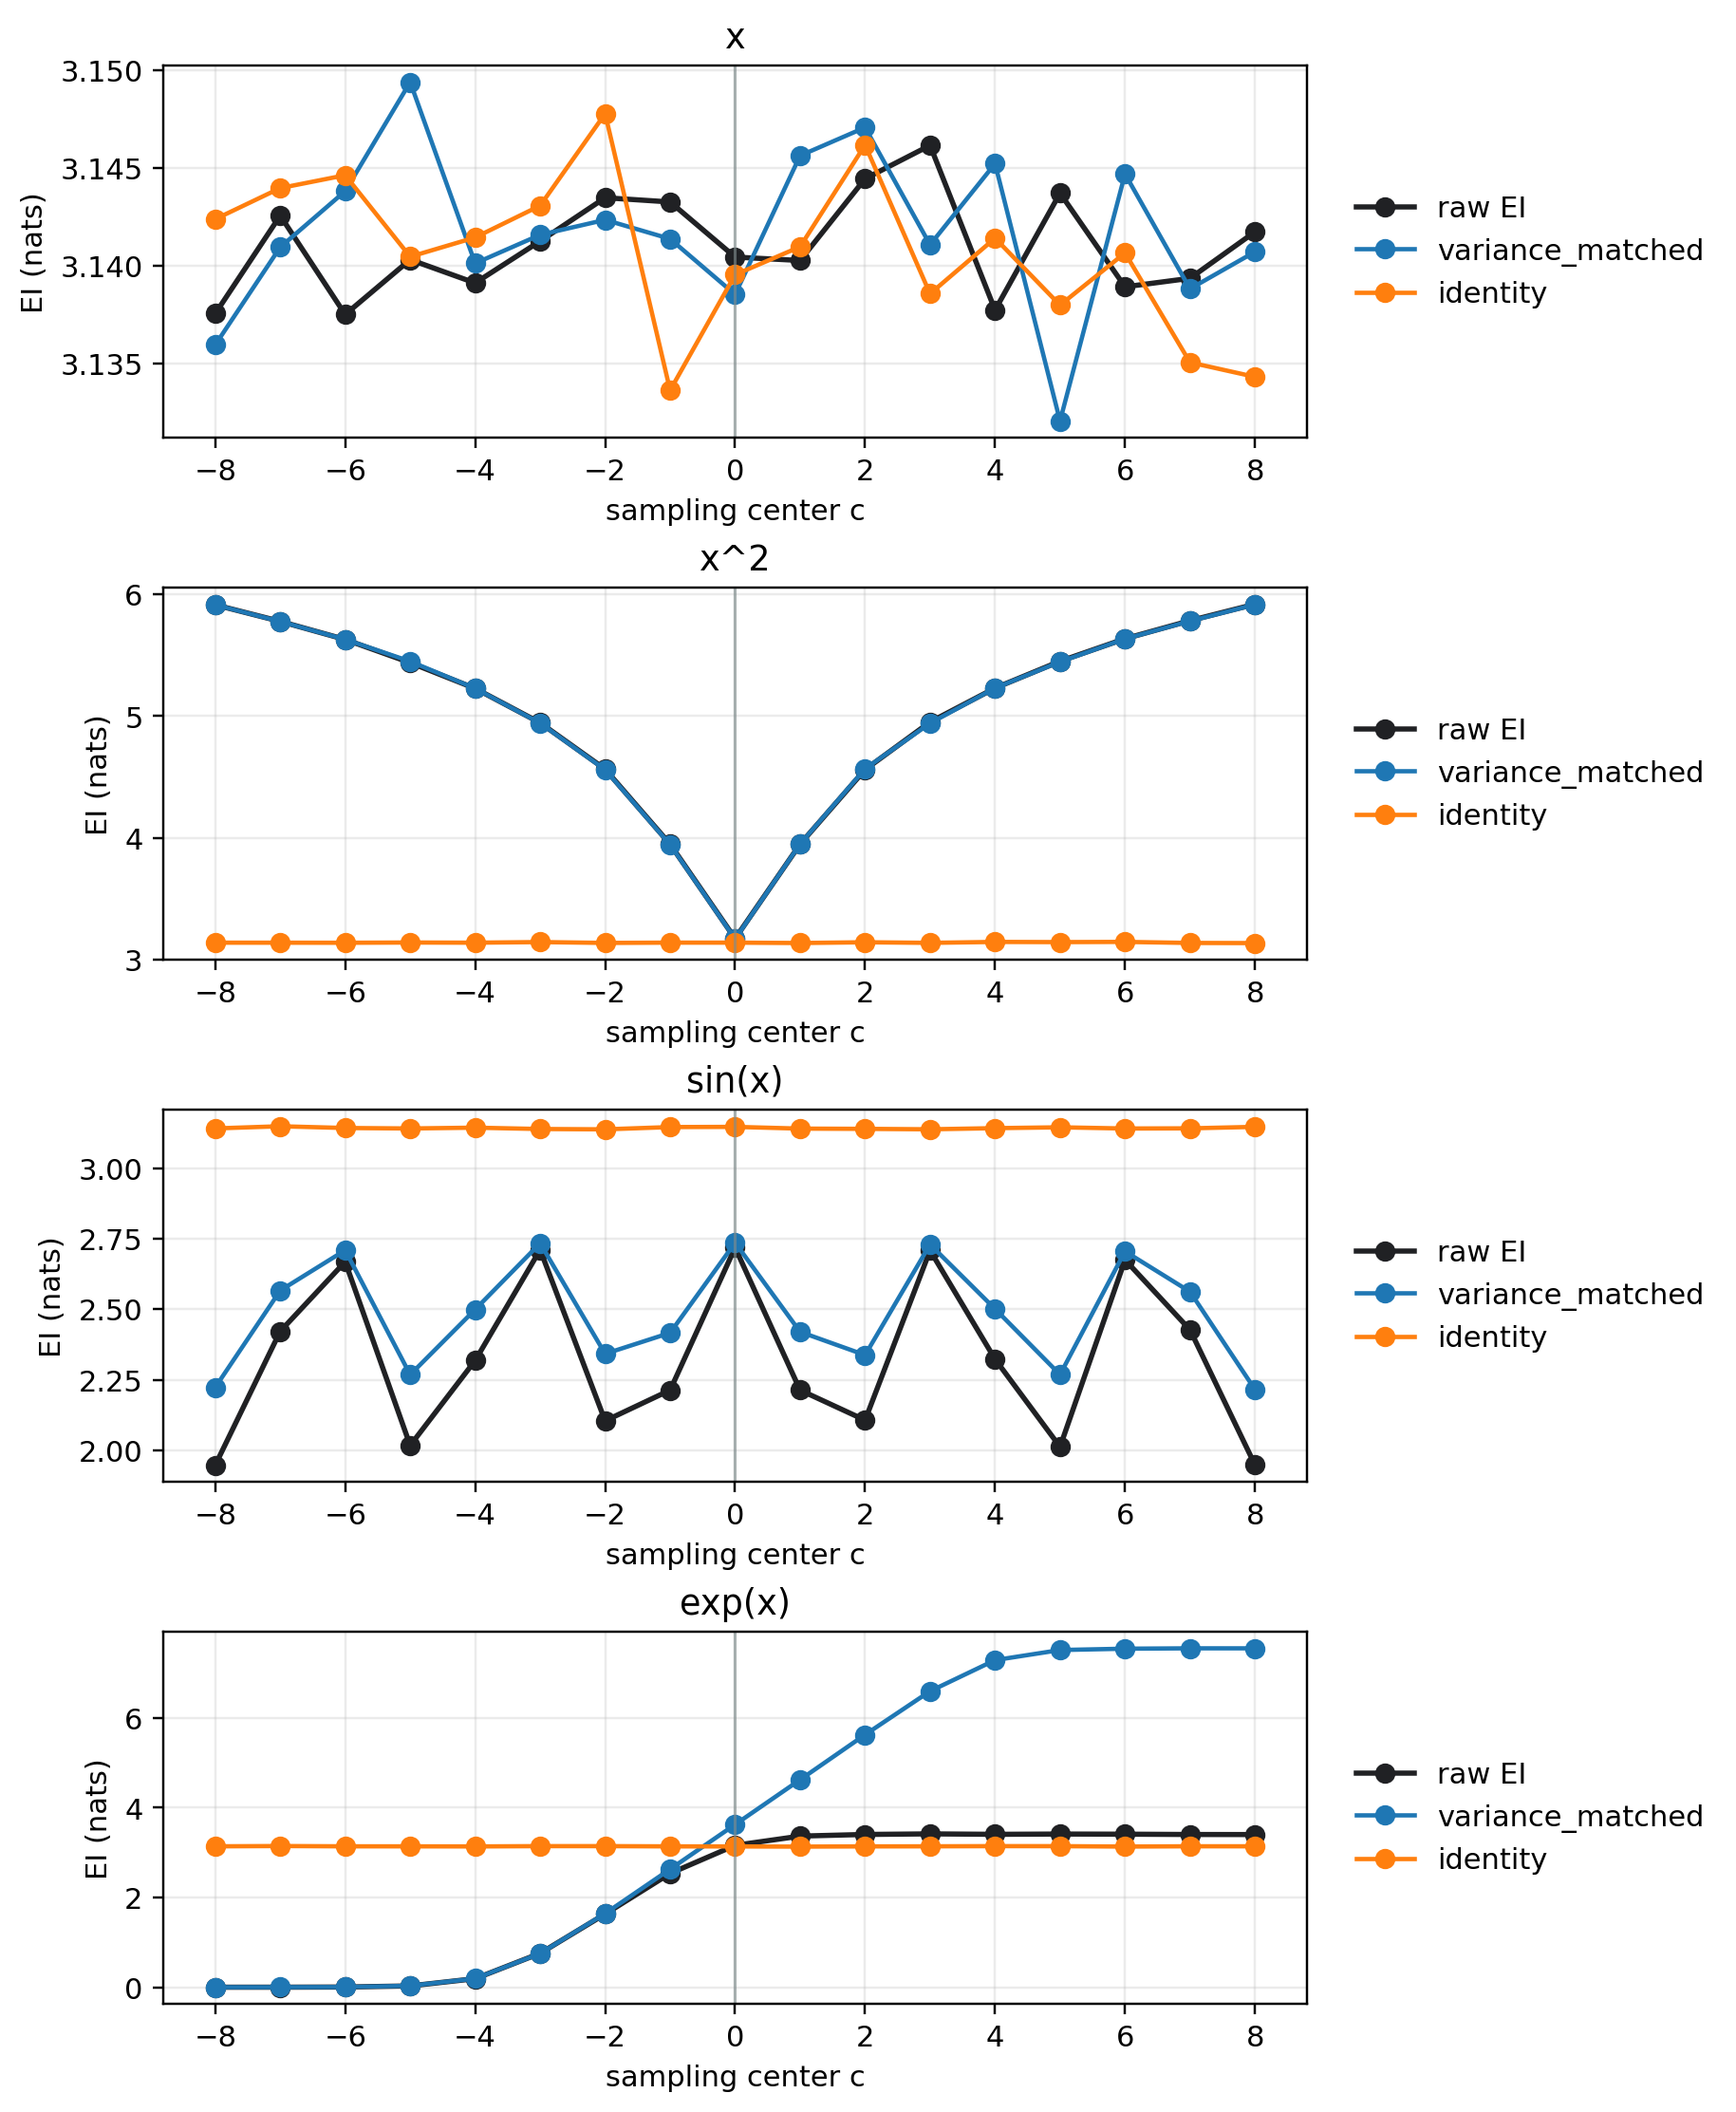

{'center_runs': (680, 11),
 'center_baselines': (1360, 13),
 'center_curve': (204, 7),
 'center_artifacts': {'runs_csv': '/Users/yangmingzhe/Desktop/code/github/EISyn/fig/transport_map_mutual_information/tm_ei_center_sweep_runs.csv',
  'baselines_csv': '/Users/yangmingzhe/Desktop/code/github/EISyn/fig/transport_map_mutual_information/tm_ei_center_sweep_baselines.csv',
  'curve_csv': '/Users/yangmingzhe/Desktop/code/github/EISyn/fig/transport_map_mutual_information/tm_ei_center_sweep_curve.csv',
  'manifest_json': '/Users/yangmingzhe/Desktop/code/github/EISyn/fig/transport_map_mutual_information/tm_ei_center_sweep_manifest.json'},
 'center_curves': ['/Users/yangmingzhe/Desktop/code/github/EISyn/fig/transport_map_mutual_information/tm_ei_center_sweep_raw_curves.png',
  '/Users/yangmingzhe/Desktop/code/github/EISyn/fig/transport_map_mutual_information/tm_ei_center_sweep_raw_curves.pdf']}

In [3]:
CENTER_CONFIG = {
    'center_values': tuple(np.linspace(-4.0, 4.0, 3)) if TEST_MODE else tuple(np.linspace(-8.0, 8.0, 17)),
    'l_value': 4.0,
    'dynamics_specs': REQUESTED_ONE_DIMENSIONAL_DYNAMICS_SPECS,
    'baselines': top2_baselines,
    'n_samples': 256 if TEST_MODE else 4096,
    'repeats': 1 if TEST_MODE else 10,
    'base_noise_std': 0.05,
    'seed': SEED + 500000,
}

center_results = run_ei_center_sweep(**CENTER_CONFIG)
center_runs = center_results['runs']
center_baselines = center_results['baselines']

center_png, center_pdf, center_curve = plot_raw_ei_by_center(
    center_runs,
    center_baselines,
    output_dir=OUTPUT_DIR,
    dynamics_labels=tuple(dict.fromkeys(center_runs['label'].tolist())),
    baselines=top2_baselines,
    output_stem='tm_ei_center_sweep_raw_curves',
)
center_results['curve'] = center_curve
center_artifact_paths = write_center_sweep_artifacts(
    results=center_results,
    output_dir=OUTPUT_DIR,
    notebook_path='exp/tm_ei_l_baseline.ipynb',
    config={
        **CENTER_CONFIG,
        'center_values': [float(value) for value in CENTER_CONFIG['center_values']],
        'dynamics_specs': [dict(spec) for spec in CENTER_CONFIG['dynamics_specs']],
        'baselines': list(CENTER_CONFIG['baselines']),
        'test_mode': TEST_MODE,
    },
)

display(Image(filename=str(center_png)))
{
    'center_runs': center_runs.shape,
    'center_baselines': center_baselines.shape,
    'center_curve': center_curve.shape,
    'center_artifacts': center_artifact_paths,
    'center_curves': [str(center_png), str(center_pdf)],
}


## 为什么 $L$ 变大会让 EI 变化

改变 $L$ 等价于改变干预分布本身，而不是在同一个输入分布上重复测量：

$$
x\sim \mathrm{Uniform}([-L/2,L/2]),\qquad H(x)=\log L .
$$

固定噪声下，$L$ 变大会增加输入可区分状态数，也会改变 $F(x)$ 的输出尺度。在线性近似 $y=ax+\epsilon$ 下，

$$
\operatorname{Var}(x)=\frac{L^2}{12},\qquad
I(x;y)\approx \frac12\log\!\left(1+\frac{a^2L^2}{12\sigma^2}\right).
$$

所以只要噪声标准差 $\sigma$ 固定，扩大 $L$ 往往会提高信噪比并推高 $EI$。不同动力学的差异来自函数形状：$x$ 基本单调线性，$x^2$ 有折叠但输出方差随 $L^2$ 增长，$\sin(x)$ 在大区间内多对一并出现周期折叠。


## 读图要点

- 黑线 `raw EI` 是 $EI_{\mathrm{raw}}(L)$。
- 蓝线和橙线是 baseline 本身 $B_b(L)$，不是 $EI_{\mathrm{raw}}(L)-B_b(L)$。
- 如果某条 baseline 曲线与黑线斜率接近，说明该 baseline 能解释很多由 $L$ 带来的尺度依赖。
- `identity` 主要控制恒等线性通道的 $L$ 效应。
- `variance_matched` 主要控制输出方差随 $L$ 变化带来的 $EI$ 增长，对 $x^2$、$\exp(x)$ 这类尺度变化强的动力学更关键。
